In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
adata_cancer = sc.read_h5ad('cancercell_kinetics_adata.h5ad')

In [3]:
mito_genes = adata_cancer.var_names.str.startswith('mt-')
ribo_genes = adata_cancer.var_names.str.contains('^Rp[sl]')
adata_cancer = adata_cancer[:, ~(mito_genes | ribo_genes)].copy()

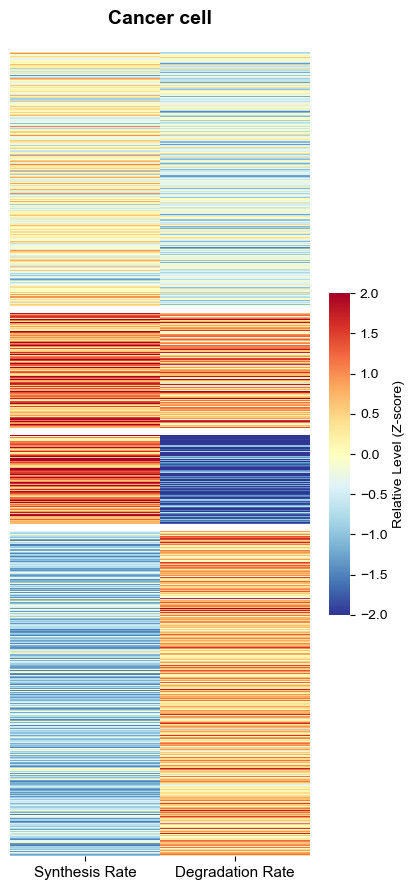

In [4]:
# 1. filter
gene_df = adata_cancer.var[['alpha_gene_cancer', 'gamma_gene_cancer']].copy()
gene_df = gene_df[(gene_df['alpha_gene_cancer'] > 0.1) & 
                  (gene_df['gamma_gene_cancer'] > 0) & 
                  (gene_df['gamma_gene_cancer'] < 3.07)]

# 2. Z-score
alpha_log = np.log10(gene_df['alpha_gene_cancer'])
gene_df['alpha_z'] = (alpha_log - alpha_log.mean()) / alpha_log.std()

gamma_raw =np.log10(gene_df['gamma_gene_cancer'])
gene_df['gamma_z'] = (gamma_raw - gamma_raw.mean()) / gamma_raw.std()

# 3. K-Means
n_clusters = 4 
features = gene_df[['alpha_z', 'gamma_z']].values
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
gene_df['Cluster_ID'] = kmeans.fit_predict(features)
gene_df['Cluster'] = 'Cluster ' + gene_df['Cluster_ID'].astype(str)
custom_order = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 0']
gene_df['Cluster'] = pd.Categorical(gene_df['Cluster'], categories=custom_order, ordered=True)
gene_df['gene_name'] = gene_df.index
gene_df = gene_df.sort_values(by=['Cluster']).reset_index(drop=True)

heatmap_data = gene_df[['alpha_z', 'gamma_z']].copy()
heatmap_data.columns = ['Synthesis Rate', 'Degradation Rate']

# 4. heatmap
fig, ax = plt.subplots(figsize=(6, 9))

sns.heatmap(
    heatmap_data, 
    cmap='RdYlBu_r', 
    center=0, 
    vmin=-2, vmax=2,
    cbar_kws={'label': 'Relative Level (Z-score)', 'shrink': 0.4, 'aspect': 15},
    yticklabels=False, 
    ax=ax,
    rasterized=True 
)

cluster_counts = gene_df['Cluster'].value_counts().sort_index()
current_idx = 0

for cluster_name, count in cluster_counts.items():
    next_idx = current_idx + count
    
    if current_idx > 0:
        ax.axhline(current_idx, color='white', linewidth=5, zorder=10)
    
    current_idx = next_idx

ax.set_title('Cancer cell', fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', labelsize=11, rotation=0)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.subplots_adjust(right=0.65) 
# plt.savefig('Fig4_Cancercell_heatmap_cluster4.pdf', bbox_inches='tight', dpi=300)
plt.show()

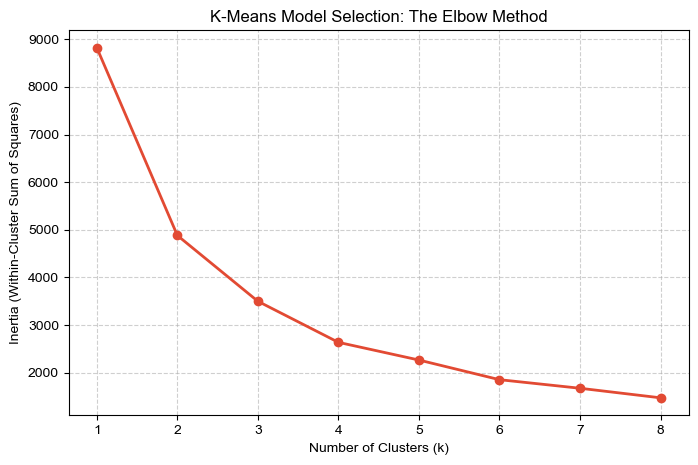

In [8]:
features = gene_df[['alpha_z', 'gamma_z']].values
n_components_range = range(1, 9)
inertia_scores = []

for n in n_components_range:
    kmeans = KMeans(n_clusters=n, random_state=42, n_init='auto')
    kmeans.fit(features)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, inertia_scores, marker='o', color='#E24A33', linewidth=2)
plt.title('K-Means Model Selection: The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(n_components_range)
plt.grid(True, linestyle='--', alpha=0.6)
# plt.savefig('SI_Cancercell_K-means.pdf', bbox_inches='tight', dpi=300)
plt.show()


 Alpha Top 5
      alpha_gene_cancer  gamma_gene_cancer
1799          49.586791           1.414488
1859           5.526128           0.502696
1998           3.644315           0.519576
2012           3.476197           0.382717
1847           3.120760           0.547305

 Gamma Top 5
      gamma_gene_cancer  alpha_gene_cancer
1799           1.414488          49.586791
1796           0.704835           1.612062
1819           0.701558           1.606484
1689           0.696397           2.499940
1467           0.663661           1.409057

 total gene : 9 



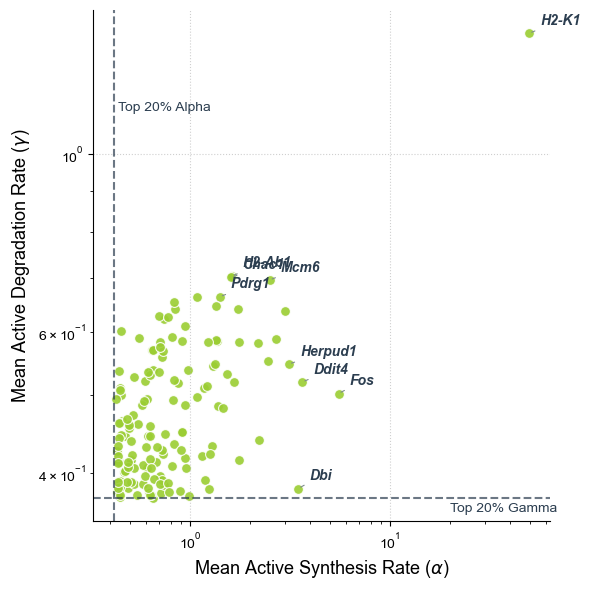

In [7]:

# 1. calc Top 20% 
alpha_threshold = gene_df['alpha_gene_cancer'].quantile(0.80)
gamma_threshold = gene_df['gamma_gene_cancer'].quantile(0.80)

top20_df = gene_df[(gene_df['alpha_gene_cancer'] >= alpha_threshold) & 
                   (gene_df['gamma_gene_cancer'] >= gamma_threshold)].copy()

top5_alpha = top20_df.sort_values(by='alpha_gene_cancer', ascending=False).head(5)
print("\n Alpha Top 5")
print(top5_alpha[['alpha_gene_cancer', 'gamma_gene_cancer']])

top5_gamma = top20_df.sort_values(by='gamma_gene_cancer', ascending=False).head(5)
print("\n Gamma Top 5")
print(top5_gamma[['gamma_gene_cancer','alpha_gene_cancer' ]])

top_genes_combined = pd.concat([top5_alpha, top5_gamma]).drop_duplicates()
print(f"\n total gene : {len(top_genes_combined)} \n")


# 2. scatterplot
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=top20_df, 
    x='alpha_gene_cancer', 
    y='gamma_gene_cancer',
    color='#9ACD32',     
    alpha=0.9,           
    s=50,                
    edgecolor='white',   
    linewidth=0.8
)

plt.axvline(x=alpha_threshold, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=gamma_threshold, color='#2c3e50', linestyle='--', linewidth=1.5, alpha=0.7)

plt.text(alpha_threshold * 1.05, top20_df['gamma_gene_cancer'].max() * 0.8, 
         f"Top 20% Alpha", color='#2c3e50', fontsize=10)
plt.text(top20_df['alpha_gene_cancer'].max() * 0.4, gamma_threshold * 0.96, 
         f"Top 20% Gamma", color='#2c3e50', fontsize=10)

for gene_name, row in top_genes_combined.iterrows():
    plt.annotate(
        row['gene_name'],
        (row['alpha_gene_cancer'], row['gamma_gene_cancer']),
        textcoords="offset points", 
        xytext=(8, 6),      
        ha='left',           
        fontsize=10,
        fontweight='bold',
        fontstyle='italic',  
        color='#2c3e50',
        arrowprops=dict(arrowstyle='-', color='#7f8c8d', lw=0.8) 
    )

plt.xlabel("Mean Active Synthesis Rate ($\\alpha$)", fontsize=13)
plt.ylabel("Mean Active Degradation Rate ($\\gamma$)", fontsize=13)

plt.grid(True, linestyle=':', alpha=0.6)
sns.despine()
plt.xscale('log')
plt.yscale('log')
# plt.savefig('final_cc_top20p_scatter.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()